## Imports and Filters

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from math import ceil
from pathlib import Path
import re
from langdetect import detect, detect_langs, LangDetectException, DetectorFactory
import sys
import nltk
from nltk.corpus import stopwords

DetectorFactory.seed = 0
nltk.download('stopwords')

In [2]:
songs = pd.read_csv('dataset/songs.csv')
print(len(songs))
songs.head(3)

491632


,id,name,album_name,artists,danceability,energy,key,loudness,mode,speechiness,...,tempo,duration_ms,lyrics,year,genre,popularity,total_artist_followers,avg_artist_popularity,artist_ids,niche_genres
0,2ASl4wirkeYm3OWZxXKYuq,!!,Childhood Dreams,"[""Yxngxr1""]",0.788,0.648,7,-9.135,0,0.315,...,79.998,114000,"Fuck the bitch, now she running with my kids\n...",2019,Hip-Hop,29,143628,45.0,"[""2jwRHcdgkRhelYEMqndDKe""]",[]
1,5tA3ImW310llKo8EMBj2Ga,!!Noble Stabbings!!,Situationist Comedy,"[""Dillinger Four""]",0.171,0.957,2,-5.749,1,0.149,...,175.317,197400,You like to stand on the other side\nPoint and...,2002,Rock,0,36619,35.0,"[""4YAN46l70QV0PGXlMg0iHi""]","[""melodic hardcore"", ""pop punk"", ""punk"", ""skat..."
2,0fROT4kK5oTm8xO8PX6EJF,!I'll Be Back!,!I'll Be Back!,"[""Ril\u00e8s""]",0.823,0.612,1,-7.767,1,0.248,...,142.959,178533,"It's been a while, shit, I missed the rehab, p...",2018,Hip-Hop,43,929303,63.0,"[""6pdcQa7by8IKuoVXvgknlI""]","[""french rap""]"


In [3]:
songs['year'].value_counts().sort_index(ascending=False)

year
2025        2
2024        1
2023     5566
2022    18298
2021    13759
        ...  
1925       15
1924        4
1923       26
1917        2
1900       29
Name: count, Length: 105, dtype: int64

In [4]:
filtered = songs[
    (songs['popularity'] > 0) &
    (songs['lyrics'].notna()) &
    (songs['lyrics'].str.strip() != '') &
    (songs['year'] <= 2023)
].sort_values('popularity', ascending=False) \
    .drop_duplicates(subset=['name', 'artists'], keep='first') \
    .copy().reset_index(drop=True)
print('Filtered songs (popularity > 0, non-empty lyrics, tracks from 2023 and below)')
print(f'Rows   : {len(filtered):,}')
print(f'Columns: {filtered.shape[1]}')
display(filtered.head(3))

Filtered songs (popularity > 0, non-empty lyrics, tracks from 2023 and below)
Rows   : 327,883
Columns: 24


,id,name,album_name,artists,danceability,energy,key,loudness,mode,speechiness,...,tempo,duration_ms,lyrics,year,genre,popularity,total_artist_followers,avg_artist_popularity,artist_ids,niche_genres
0,0bYg9bo50gSsH3LtXe2SQn,All I Want for Christmas Is You,Merry Christmas,"[""Mariah Carey""]",0.336,0.627,7,-7.463,1,0.0384,...,150.273,241107,I don't want a lot for Christmas\nThere is jus...,1994,Pop,98,12195308,87.0,"[""4iHNK0tOyZPYnBU7nGAgpQ""]","[""christmas""]"
1,2EjXfH91m7f8HiJN1yQg97,Rockin' Around The Christmas Tree,Merry Christmas From Brenda Lee,"[""Brenda Lee""]",0.598,0.470,8,-8.744,1,0.0496,...,67.086,126267,Rocking around the Christmas tree\nAt the Chri...,1964,Pop,98,486951,80.0,"[""4cPHsZM98sKzmV26wlwD2W""]","[""christmas""]"
2,2FRnf9qhLbvw8fu4IBXx78,Last Christmas,LAST CHRISTMAS,"[""Wham!""]",0.735,0.478,2,-12.472,1,0.0293,...,107.682,262960,"Oh, oh-oh, ooh-oh-oh-oh\nAh-ah\n\nLast Christm...",1984,Pop,98,3205723,82.0,"[""5lpH0xAS4fVfLkACg9DAuM""]","[""christmas""]"


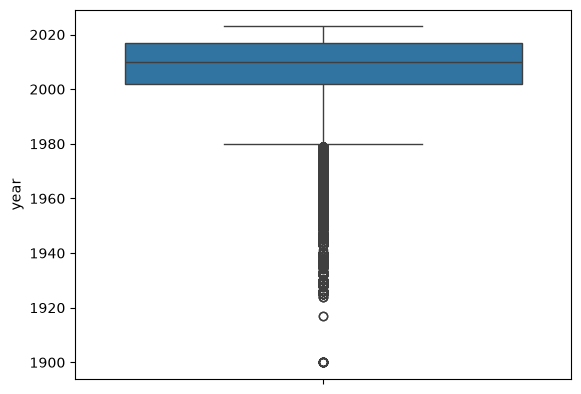

In [5]:
sns.boxplot(data=filtered, y='year')
plt.show()

In [6]:
# filtered to be 2000-2023
filtered = filtered[filtered['year'] >= 2000].reset_index(drop=True)
print(f'Rows   : {len(filtered):,}')
print(f'Columns: {filtered.shape[1]}')
print()
print(filtered['year'].value_counts().sort_index(ascending=False))

old_filtered_len = len(filtered)

Rows   : 263,575
Columns: 24

year
2023     3574
2022    11322
2021    10664
2020    15011
2019    15976
2018    15773
2017    14835
2016    12079
2015    12411
2014    12280
2013    12037
2012    11797
2011    10588
2010    10294
2009    10463
2008    10168
2007    10639
2006    10667
2005    10152
2004     9287
2003     9032
2002     8452
2001     8168
2000     7906
Name: count, dtype: int64


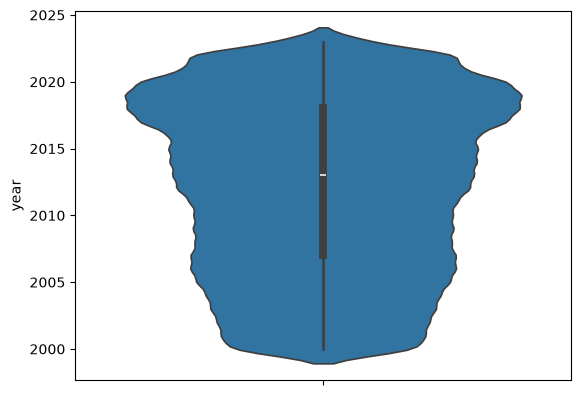

In [7]:
sns.violinplot(data=filtered, y='year')
plt.show()

---
## Lyrics Cleaning and Check

In [8]:
# escape sequence check on lyrics

def scan_escape_sequences(filtered, column='lyrics'):
    """
    Scans a single DataFrame for literal escape sequences (e.g. \n, \t, \', \")
    appearing in a text column. Reports counts and example rows per escape type.
    """
    # common literal escape sequences to check for
    escape_patterns = {
        r'\n': r'\\n',
        r'\t': r'\\t',
        r'\r': r'\\r',
        r"\'": r"\\'",
        r'\"': r'\\"',
        r'\\': r'\\\\',
        r'\u': r'\\u[0-9a-fA-F]{4}',   # \uXXXX unicode escapes
        r'\x': r'\\x[0-9a-fA-F]{2}',   # \xXX hex escapes
    }

    print(f"Scanning column '{column}' (n={len(filtered)})")
    print('=' * 50)

    if column not in filtered.columns:
        print(f"  Column '{column}' not found.")
        return

    texts = filtered[column].dropna().astype(str)
    found_any = False

    for name, pattern in escape_patterns.items():
        matches = texts.str.contains(pattern, regex=True, na=False)
        count = matches.sum()

        if count > 0:
            found_any = True
            print(f"  '{name}' literal escape found in {count} rows ({count/len(texts)*100:.1f}%)")

            # show one example, truncated, with context around the match
            example_text = texts[matches].iloc[0]
            match_obj = re.search(pattern, example_text)
            if match_obj:
                start = max(0, match_obj.start() - 30)
                end = min(len(example_text), match_obj.end() + 30)
                snippet = example_text[start:end]
                print(f"    example: ...{snippet}...")

    if not found_any:
        print("  No literal escape sequences found.")


# example usage on a single dataframe
scan_escape_sequences(filtered)

Scanning column 'lyrics' (n=263575)
  '\n' literal escape found in 36 rows (0.0%)
    example: ...nging
Ooh It's Christmas ooh

\n it's Christmas ooh

Piano sol...
  '\'' literal escape found in 23 rows (0.0%)
    example: ...I should be patient
but can\'t hardly wait
something I want...
  '\"' literal escape found in 24 rows (0.0%)
    example: ... burn young fire When you say \""fight back\"" our love won't ...
  '\\' literal escape found in 1 rows (0.0%)
    example: ...a)
Tm (amarte Como Te Amo)
You\\\¸re Just Another Winner (risa...
  '\u' literal escape found in 1 rows (0.0%)
    example: ...f this\nLovely, lovely night\n\u266a\nThe stars in a hazy heaven t...


In [9]:
# index col
try:
    filtered.drop(columns=['index'], inplace=True)
except:
    pass
filtered.reset_index(inplace=True)

# lyrics cleaned
filtered['lyrics'] = (
    filtered['lyrics']
    .str.lower()
    .str.replace(r'\\u([0-9a-fA-F]{4})', lambda m: chr(int(m.group(1), 16)), regex=True)  # \uXXXX -> actual unicode char
    .str.replace(r'\\n', ' ', regex=True)   # literal \n -> space
    .str.replace(r'\\r', ' ', regex=True)   # literal \r -> space (just in case)
    .str.replace(r'\\t', ' ', regex=True)   # literal \t -> space
    .str.replace(r'\\"', '"', regex=True)   # literal \" -> "
    .str.replace(r"\\'", "'", regex=True)   # literal \' -> '
    .str.replace(r'\\\\', '', regex=True)   # stray literal backslashes -> remove
    .str.replace(r'\s+', ' ', regex=True)   # collapse multiple spaces/real newlines into one
    .str.strip()
)

# valid lyrics col as temp True
filtered['is_valid_lyrics'] = True

In [10]:
# index and lyrics
display(filtered['index'].value_counts())

scan_escape_sequences(filtered)
print()
print('=== BEFORE ===')
print(songs['lyrics'][0])
print()
print('=== AFTER ===')
print(filtered['lyrics'][0])

index
0         1
1         1
2         1
3         1
4         1
         ..
263570    1
263571    1
263572    1
263573    1
263574    1
Name: count, Length: 263575, dtype: int64

Scanning column 'lyrics' (n=263575)
  No literal escape sequences found.

=== BEFORE ===
Fuck the bitch, now she running with my kids\nAnd you said I never listen\nYeah, yeah\nYeah, yeah, yeah\nTell me all the things 'bout your family\nStruggle with your words, said you're rambling\nAlways play a game, bet you're gambling\nBut you got me on a string and I'm dancing\nTell me your childhood TV shows\nTell me something that I could run with\nSo I feel lucky\nSo I feel lucky, yeah\nI'm only here for love\nTell me all the things about you\nBaby, I won't know\nI'm only here for love\nTell me all the things about you\nBaby, I won't know\nI'm only here for love\nTell me all the things about you\nBaby, I won't know\nI'm only here for love, oh-oh, oh-oh\nGot a tough heart 'cause your rough start\nBut you love cars and I love stars\nAnd your main dream is the only thing you see\nBut you never fuck with me, but I'm older than I seem, yeah\nComing home to you, baby\nAnd the way you flick your hair 

In [11]:
filtered['is_valid_lyrics']

0         True
1         True
2         True
3         True
4         True
          ... 
263570    True
263571    True
263572    True
263573    True
263574    True
Name: is_valid_lyrics, Length: 263575, dtype: bool

---
## Lyrics Validation Testing

In [12]:
Path('logs').mkdir(parents=True, exist_ok=True)

# Get a list of the most common structural English words
common_stop_words = set(stopwords.words('english'))
print(len(common_stop_words))
print(list(common_stop_words)[:15])

# adding to stopwords
ENGLISH_COMMON_WORDS = common_stop_words.union({'like', 'hate'})
common_stop_words ^ ENGLISH_COMMON_WORDS

198
['won', "aren't", 'down', 'ours', 'from', "she'll", "won't", 'an', 'for', 'hadn', 'i', 'been', "she's", 'shan', 'if']


{'hate', 'like'}

In [13]:
# Remove common LRCLIB / metadata artifacts, e.g. [Chorus], [Verse 1], timestamps
def clean_lyrics(lyrics):
    cleaned = re.sub(r'\[.*?\]', '', lyrics)
    cleaned = re.sub(r'\d{1,2}:\d{2}(\.\d+)?', '', cleaned)  # strip LRC timestamps like 00:12.34
    cleaned = cleaned.strip()
    return cleaned

# stopword fallback function in case of false non-English language
def looks_english(text, min_ratio=0.15):
    words = re.findall(r'\b[a-z]+\b', text.lower())
    if not words:
        return False
    common_count = sum(1 for w in words if w in ENGLISH_COMMON_WORDS)
    return (common_count / len(words)) >= min_ratio

# lyrics validation function
def is_lyrics_valid(lyrics, index, min_words=20, max_non_ascii_ratio=0.15):
    """
    Checks whether a lyrics string is valid, non-empty, sufficiently long,
    and detected as English. Returns True/False.
    """
    print(f'Track index: {index:<7} |', end=' ')

    if not isinstance(lyrics, str) or not lyrics.strip():
        print('❌ INVALID -> lyrics missing or empty')
        return False

    cleaned = clean_lyrics(lyrics)

    if not cleaned:
        print('❌ INVALID -> empty after stripping metadata/timestamps')
        return False

    # Filter out instrumental / placeholder entries
    placeholder_terms = {"instrumental", "no lyrics", "lyrics not available"}
    if cleaned.lower() in placeholder_terms:
        print(f'❌ INVALID -> placeholder text ("{cleaned.lower()}")')
        return False

    # Minimum length check — avoids junk/very short entries skewing VADER scores
    word_count = len(cleaned.split())
    if word_count < min_words:
        print(f'❌ INVALID -> too short ({word_count} words, min {min_words})')
        return False

    # Reject entries with a high ratio of non-ASCII characters —
    # catches mojibake / non-Latin-script text mixed with stray English words
    non_ascii = sum(1 for c in cleaned if ord(c) > 127)
    non_ascii_ratio = non_ascii / len(cleaned)
    if non_ascii_ratio > max_non_ascii_ratio:
        print(f'❌ INVALID -> non-ASCII ratio too high ({non_ascii_ratio:.2%}, max {max_non_ascii_ratio:.0%})')
        return False

    # Language detection
    try:
        lang = detect(cleaned)
    except LangDetectException:
        print('❌ INVALID -> language detection failed')
        return False

    if lang != 'en' and not looks_english(cleaned):
        print(f'❌ INVALID -> detected language "{lang}", not English')
        return False

    print(f'✅ VALID -> {word_count} words, non-ASCII ratio {non_ascii_ratio:.2%}')
    return True

In [14]:
# Validate whether min_ratio=0.15 is a meaningful threshold for looks_english(),
# by sampling first (to avoid recomputing langdetect/ratio on the full dataset),
# then checking precision/recall against a manual ground-truth label

# Step 1: take a random sample from filtered FIRST (cheap), before running langdetect on it
sample_size = 5000
sample = filtered.sample(n=min(sample_size, len(filtered))).copy()

# Step 2: only now compute cleaned lyrics, langdetect result, and common_word_ratio — on the sample only
def get_langdetect_result(text):
    try:
        return detect(text)
    except LangDetectException:
        return 'unknown'

def common_word_ratio(text):
    words = re.findall(r'\b[a-z]+\b', text.lower())
    if not words:
        return 0.0
    common_count = sum(1 for w in words if w in ENGLISH_COMMON_WORDS)
    return common_count / len(words)

sample['cleaned_lyrics'] = sample['lyrics'].apply(clean_lyrics)
sample['langdetect_result'] = sample['cleaned_lyrics'].apply(get_langdetect_result)
sample['common_word_ratio'] = sample['cleaned_lyrics'].apply(common_word_ratio)

# Step 3: narrow down to only the fallback-triggered subset (where looks_english is the deciding vote)
fallback_sample = sample[sample['langdetect_result'] != 'en'].copy()
fallback_sample['looks_english_verdict'] = fallback_sample['common_word_ratio'] >= 0.15

print(f"Sampled tracks: {len(sample)}")
print(f"Fallback-triggered tracks in sample: {len(fallback_sample)}")
print(f"Fallback pass rate at 0.15: {fallback_sample['looks_english_verdict'].mean()*100:.2f}%\n")

# Step 4: add a blank column to manually label directly in the dataframe
fallback_sample['manual_label'] = 'en'  # fill in manually below: 'english', 'non_english', or 'garbage'

display(fallback_sample[['id', 'name', 'artists', 'cleaned_lyrics', 'common_word_ratio',
                  'looks_english_verdict', 'manual_label']])

# Step 5: run AFTER manually filling in fallback_sample['manual_label']
labeled = fallback_sample[fallback_sample['manual_label'] != '']

if len(labeled) == 0:
    print("⚠️ No manual labels found yet — fill in fallback_sample['manual_label'] first.")
else:
    labeled = labeled.copy()
    labeled['ground_truth_english'] = labeled['manual_label'] == 'en'

    for t in np.arange(0.15, 0.55, 0.05):
        pred = labeled['common_word_ratio'] >= t
        tp = ((pred) & (labeled['ground_truth_english'])).sum()
        fp = ((pred) & (~labeled['ground_truth_english'])).sum()
        fn = ((~pred) & (labeled['ground_truth_english'])).sum()
        precision = tp / (tp + fp) if (tp + fp) > 0 else float('nan')
        recall = tp / (tp + fn) if (tp + fn) > 0 else float('nan')
        print(f"threshold={t:.2f} | precision={precision:.3f} | recall={recall:.3f}")

Sampled tracks: 5000
Fallback-triggered tracks in sample: 25
Fallback pass rate at 0.15: 80.00%



,id,name,artists,cleaned_lyrics,common_word_ratio,looks_english_verdict,manual_label
139292,4w2Fpy28EKJyBT1RnX6SVu,Get On Up - Getter Remix,"[""Jauz"", ""Pegboard Nerds"", ""Getter""]",get on up! 'cause your body really needs it (g...,0.625571,True,en
2836,5vOT8VO87TAnUjh0oADwb1,Go Go,"[""BTS""]","dollar, dollar 全て無くすまで まだまだ 走り稼ぐだけ まだまだ まだまだ ま...",0.240602,True,en
18229,1iN31yt7y7vREKboJoPvvw,On the way,"[""NCT DREAM""]",내일이 여전히 아득한데 회색빛 하늘은 잠이 들지 한숨을 떨구는 네 모습이 비친 듯해...,0.572581,True,en
249548,1rHBIM9mUEozt41jfhIgYQ,エクスキューザー,"[""BRATS""]",狂気の思想 絡まる感情 字に埋まる夜 遮る夢想 速まる鼓動 汗ばんじゃって 臨界オーバー 論...,0.693548,True,en
3035,5cpJFiNwYyWwFLH0V6B3N8,Del Mar,"[""Ozuna"", ""Doja Cat"", ""Sia""]","yeah-eh ozuna se pierde en la arena y el mar, ...",0.074492,False,en
18702,43mNwDn0zOH2HKl5B4aqcx,Falling,"[""Alesso""]","right here, right now, it's all we need relax ...",0.542773,True,en
14070,2a5qaGUrVHWAIrh0xmTADM,neve give up,"[""Son Little""]",with a club in hand and a pistol in the other ...,0.488318,True,en
227773,2CrkwIjv0EyImBlLIWSJc0,Right String But The Wrong Yo Yo,"[""Carl Perkins""]","celosa me tienes cansado, triste y aburrido de...",0.136364,False,en
93513,6mOofVIiHmXHlvEapIN8k9,Masterblade - Original Mix,"[""Blademasterz""]","ladies and gentlemen, welcome, i'm your dj ♪ l...",0.444444,True,en
200789,3FeyblIh2VWwH5XhWmSuyA,Oh Eh Oh Eh,"[""Gipsy Kings""]",aquí ha llegado la hora de cantarte a ti con a...,0.104839,False,en


threshold=0.15 | precision=1.000 | recall=0.800
threshold=0.20 | precision=1.000 | recall=0.760
threshold=0.25 | precision=1.000 | recall=0.720
threshold=0.30 | precision=1.000 | recall=0.680
threshold=0.35 | precision=1.000 | recall=0.520
threshold=0.40 | precision=1.000 | recall=0.480
threshold=0.45 | precision=1.000 | recall=0.360
threshold=0.50 | precision=1.000 | recall=0.280


**Track lyrics flagged wrongly**

Correct with non-nlbk stopword fallback
- 3597
- 5265
- 80847
- 255840
- 287621

Still wrong before nlbk common stopwords
- 107645
- 134109
- 208721
- 280573

In [29]:
# single lyrics check
val = None
song_index = val if val != None else filtered.sample(1).index[0]
test_song = filtered.iloc[song_index]

is_lyrics_valid(
    index=song_index,
    lyrics=test_song['lyrics']
)
print('\nLYRICS:\n' + test_song['lyrics'])
print('\nDETECTED LANG %: ' + str(detect_langs(clean_lyrics(test_song['lyrics']))))

Track index: 201310  | ✅ VALID -> 154 words, non-ASCII ratio 0.00%

LYRICS:
(look, look, look-a, look who's blue) please, please, have pity on me oh, can't you see that i'm in misery please, please, i'm beggin' like a fool woe is me, look who's blue i said no gal's gonna ever tie me down i'm goin' out every night and paint the town well i was doin' fine till i met you woe is me, look who's blue please, please, have pity on me oh, can't you see that i'm in misery please, please, i'm beggin' like a fool woe is me, look who's blue i said there'd never be just one for me and i'm gonna stay footloose and fancy free no gal's gonna ever tell me what to do woe is me, look who's blue please, please, have pity on me oh, can't you see that i'm in misery please, please, i'm beggin' like a fool woe is me, look who's blue woh-oh, blue

DETECTED LANG %: [en:0.999995869665889]


In [31]:
# # test validation

sample_size = 5000
test_path = 'logs/valid_lyrics_test_samples.txt'
df = filtered.sample(sample_size).reset_index()

with open(test_path, 'w', encoding='utf-8') as log_file:
    old_stdout = sys.stdout
    sys.stdout = log_file
    df['is_valid_lyrics'] = df.apply(
        lambda row: is_lyrics_valid(index=row['index'], lyrics=row['lyrics']),
        axis=1
    )
    sys.stdout = old_stdout
    display(df['is_valid_lyrics'].value_counts())

print(f"Done. Log saved to {test_path}")
display(df[df['is_valid_lyrics'] == False][['index', 'name', 'lyrics', 'is_valid_lyrics']].reset_index(drop=True))

is_valid_lyrics
True     4912
False      88
Name: count, dtype: int64

Done. Log saved to logs/valid_lyrics_test_samples.txt


,index,name,lyrics,is_valid_lyrics
0,16494,Dreamers - Music from the FIFA World Cup Qatar...,"ألا هو لا دان ألا هو لا دان (oh, redone) ألا ه...",False
1,25922,Black Hole,"black hole na, na-na-na, na-na-na, na-na-na-na...",False
2,53781,COMPLEX,"(ha, oh yeah yeah) sometimes 바로 옆에 있는 것만 같아 왜 ...",False
3,147332,Breathe,"huh, huh breathe huh, huh hah 갈증이 나 사막 같은 숨 빈틈...",False
4,86075,My Turn to Cry - Chinese Version,我還在擁抱著 在哭泣的你 那噩夢太清晰 下一秒我也就清醒 心有些歎息 打開窗寫信 把月光幻想...,False
...,...,...,...,...
83,153196,Ain’t Gonna Dance,애써 네게 관심 없는 듯 던진 시선 끝에 마주친 두 눈 숨결마저 베일 듯한 mood...,False
84,40244,Two,you know you're the only one i need right here...,False
85,249983,幾時再見,幾時再見?! woo... ha... ha... woo... 說句再見 跟你那一天 再可...,False
86,62089,Tell Me What Is Love (D.O. Solo) - Live,ladies and gentlemen this is slow jam from d.o...,False


In [21]:
# Timing estimate for full-dataset lyrics validation

sample_size = 1000
time_per_sample_run = (8, 16)  # observed seconds for sample size (min, max)

total_records = len(filtered)  # adjust if using a specific df/list

# rate per record, based on observed timing
min_rate = time_per_sample_run[0] / sample_size  # sec/record
max_rate = time_per_sample_run[1] / sample_size  # sec/record

est_min_seconds = total_records * min_rate
est_max_seconds = total_records * max_rate

def format_time(seconds):
    minutes, sec = divmod(seconds, 60)
    hours, minutes = divmod(minutes, 60)
    if hours >= 1:
        return f"{int(hours)}h {int(minutes)}m {int(sec)}s"
    elif minutes >= 1:
        return f"{int(minutes)}m {int(sec)}s"
    else:
        return f"{sec:.1f}s"

print(f"Total records: {total_records:,}")
print(f"Observed rate: {time_per_sample_run[0]}-{time_per_sample_run[1]}s per {sample_size} samples")
print(f"Estimated time for full dataset: {format_time(est_min_seconds)} - {format_time(est_max_seconds)}")

Total records: 263,575
Observed rate: 8-16s per 1000 samples
Estimated time for full dataset: 35m 8s - 1h 10m 17s


---
## Lyrics Validation Application on Dataset

In [35]:
path = 'data_filtered'
Path(path).mkdir(parents=True, exist_ok=True)
summary_path = Path('logs/summary_valid_lyrics.txt')

def data_filtered_len(year):
    try:
        return len(pd.read_csv(f'{path}/songs_{year}.csv'))
    except:
        return len(filtered.loc[filtered['year'] == year])

def write_to_summary_log(value_counts, year, mask, valid_lyrics_sum):
    true_count = value_counts.get(True, 0)
    false_count = value_counts.get(False, 0)
    width = max(len(str(true_count)), len(str(false_count)))

    with open(summary_path, 'a+', encoding='utf-8') as summary_file:
        summary_file.seek(0)
        if not summary_file.read().__contains__(f'{year} TRACKS'):
            summary_file.write(f'=== {year} TRACKS ===\n')
            summary_file.write(f'BEFORE: {mask.sum()} tracks\n')
            summary_file.write(f'AFTER:  {valid_lyrics_sum} valid tracks\n')
            summary_file.write('is_valid_lyrics\n')
            summary_file.write(f'True     {true_count:>{width}}\n')
            summary_file.write(f'False    {false_count:>{width}}\n')
            summary_file.write('\n')

In [ ]:
for year in range(2023, 2020, -1): # 2021-2023

    print(f'=== {year} TRACKS ===')
    mask = filtered['year'] == year
    print(f'BEFORE: {mask.sum()} tracks')

    log_path = Path(f'logs/valid_lyrics_{year}.txt')
    csv_path = Path(f'{path}/songs_{year}.csv')

    if not log_path.is_file():
        with open(log_path, 'w', encoding='utf-8') as log_file:
            old_stdout = sys.stdout
            sys.stdout = log_file
            filtered.loc[mask, 'is_valid_lyrics'] = filtered.loc[mask].apply(
                lambda row: is_lyrics_valid(index=row['index'], lyrics=row['lyrics']),
                axis=1
            )
            sys.stdout = old_stdout

    df = filtered.loc[mask]
    print(f'AFTER:  {df["is_valid_lyrics"].sum()} valid tracks')
    display(df['is_valid_lyrics'].value_counts())

    if not csv_path.is_file():
        df[df['is_valid_lyrics']].to_csv(csv_path, index=False)

    value_counts = df['is_valid_lyrics'].value_counts()
    write_to_summary_log(value_counts, year, mask, df["is_valid_lyrics"].sum())

In [ ]:
for year in range(2023, 2020, -1): # 2021-2023

    print(f'=== {year} TRACKS ===')
    mask = filtered['year'] == year
    print(f'BEFORE: {mask.sum()} tracks')

    log_path = Path(f'logs/valid_lyrics_{year}.txt')
    csv_path = Path(f'{path}/songs_{year}.csv')

    if not log_path.is_file():
        with open(log_path, 'w', encoding='utf-8') as log_file:
            old_stdout = sys.stdout
            sys.stdout = log_file
            filtered.loc[mask, 'is_valid_lyrics'] = filtered.loc[mask].apply(
                lambda row: is_lyrics_valid(index=row['index'], lyrics=row['lyrics']),
                axis=1
            )
            sys.stdout = old_stdout

    df = filtered.loc[mask]
    print(f'AFTER:  {df["is_valid_lyrics"].sum()} valid tracks')
    display(df['is_valid_lyrics'].value_counts())

    if not csv_path.is_file():
        df[df['is_valid_lyrics']].to_csv(csv_path, index=False)

    value_counts = df['is_valid_lyrics'].value_counts()
    write_to_summary_log(value_counts, year, mask, df["is_valid_lyrics"].sum())

In [ ]:
for year in range(2020, 2017, -1): # 2018-2020
    
    print(f'=== {year} TRACKS ===')
    mask = filtered['year'] == year
    print(f'BEFORE: {mask.sum()} tracks')

    log_path = Path(f'logs/valid_lyrics_{year}.txt')
    csv_path = Path(f'{path}/songs_{year}.csv')

    if not log_path.is_file():
        with open(log_path, 'w', encoding='utf-8') as log_file:
            old_stdout = sys.stdout
            sys.stdout = log_file
            filtered.loc[mask, 'is_valid_lyrics'] = filtered.loc[mask].apply(
                lambda row: is_lyrics_valid(index=row['index'], lyrics=row['lyrics']),
                axis=1
            )
            sys.stdout = old_stdout

    df = filtered.loc[mask]
    print(f'AFTER:  {df["is_valid_lyrics"].sum()} valid tracks')
    display(df['is_valid_lyrics'].value_counts())

    if not csv_path.is_file():
        df[df['is_valid_lyrics']].to_csv(csv_path, index=False)

    value_counts = df['is_valid_lyrics'].value_counts()
    write_to_summary_log(value_counts, year, mask, df["is_valid_lyrics"].sum())

In [ ]:
for year in range(2017, 2014, -1): # 2015-2017

    print(f'=== {year} TRACKS ===')
    mask = filtered['year'] == year
    print(f'BEFORE: {mask.sum()} tracks')

    log_path = Path(f'logs/valid_lyrics_{year}.txt')
    csv_path = Path(f'{path}/songs_{year}.csv')

    if not log_path.is_file():
        with open(log_path, 'w', encoding='utf-8') as log_file:
            old_stdout = sys.stdout
            sys.stdout = log_file
            filtered.loc[mask, 'is_valid_lyrics'] = filtered.loc[mask].apply(
                lambda row: is_lyrics_valid(index=row['index'], lyrics=row['lyrics']),
                axis=1
            )
            sys.stdout = old_stdout

    df = filtered.loc[mask]
    print(f'AFTER:  {df["is_valid_lyrics"].sum()} valid tracks')
    display(df['is_valid_lyrics'].value_counts())

    if not csv_path.is_file():
        df[df['is_valid_lyrics']].to_csv(csv_path, index=False)

    value_counts = df['is_valid_lyrics'].value_counts()
    write_to_summary_log(value_counts, year, mask, df["is_valid_lyrics"].sum())

In [ ]:
for year in range(2014, 2011, -1): # 2012-2014

    print(f'=== {year} TRACKS ===')
    mask = filtered['year'] == year
    print(f'BEFORE: {mask.sum()} tracks')

    log_path = Path(f'logs/valid_lyrics_{year}.txt')
    csv_path = Path(f'{path}/songs_{year}.csv')

    if not log_path.is_file():
        with open(log_path, 'w', encoding='utf-8') as log_file:
            old_stdout = sys.stdout
            sys.stdout = log_file
            filtered.loc[mask, 'is_valid_lyrics'] = filtered.loc[mask].apply(
                lambda row: is_lyrics_valid(index=row['index'], lyrics=row['lyrics']),
                axis=1
            )
            sys.stdout = old_stdout

    df = filtered.loc[mask]
    print(f'AFTER:  {df["is_valid_lyrics"].sum()} valid tracks')
    display(df['is_valid_lyrics'].value_counts())

    if not csv_path.is_file():
        df[df['is_valid_lyrics']].to_csv(csv_path, index=False)

    value_counts = df['is_valid_lyrics'].value_counts()
    write_to_summary_log(value_counts, year, mask, df["is_valid_lyrics"].sum())

In [ ]:
for year in range(2011, 2007, -1): # 2008-2011

    print(f'=== {year} TRACKS ===')
    mask = filtered['year'] == year
    print(f'BEFORE: {mask.sum()} tracks')

    log_path = Path(f'logs/valid_lyrics_{year}.txt')
    csv_path = Path(f'{path}/songs_{year}.csv')

    if not log_path.is_file():
        with open(log_path, 'w', encoding='utf-8') as log_file:
            old_stdout = sys.stdout
            sys.stdout = log_file
            filtered.loc[mask, 'is_valid_lyrics'] = filtered.loc[mask].apply(
                lambda row: is_lyrics_valid(index=row['index'], lyrics=row['lyrics']),
                axis=1
            )
            sys.stdout = old_stdout

    df = filtered.loc[mask]
    print(f'AFTER:  {df["is_valid_lyrics"].sum()} valid tracks')
    display(df['is_valid_lyrics'].value_counts())

    if not csv_path.is_file():
        df[df['is_valid_lyrics']].to_csv(csv_path, index=False)

    value_counts = df['is_valid_lyrics'].value_counts()
    write_to_summary_log(value_counts, year, mask, df["is_valid_lyrics"].sum())

In [ ]:
for year in range(2007, 2003, -1): # 2004-2007

    print(f'=== {year} TRACKS ===')
    mask = filtered['year'] == year
    print(f'BEFORE: {mask.sum()} tracks')

    log_path = Path(f'logs/valid_lyrics_{year}.txt')
    csv_path = Path(f'{path}/songs_{year}.csv')

    if not log_path.is_file():
        with open(log_path, 'w', encoding='utf-8') as log_file:
            old_stdout = sys.stdout
            sys.stdout = log_file
            filtered.loc[mask, 'is_valid_lyrics'] = filtered.loc[mask].apply(
                lambda row: is_lyrics_valid(index=row['index'], lyrics=row['lyrics']),
                axis=1
            )
            sys.stdout = old_stdout

    df = filtered.loc[mask]
    print(f'AFTER:  {df["is_valid_lyrics"].sum()} valid tracks')
    display(df['is_valid_lyrics'].value_counts())

    if not csv_path.is_file():
        df[df['is_valid_lyrics']].to_csv(csv_path, index=False)

    value_counts = df['is_valid_lyrics'].value_counts()
    write_to_summary_log(value_counts, year, mask, df["is_valid_lyrics"].sum())

In [ ]:
for year in range(2003, 1999, -1): # 2000-2003

    print(f'=== {year} TRACKS ===')
    mask = filtered['year'] == year
    print(f'BEFORE: {mask.sum()} tracks')

    log_path = Path(f'logs/valid_lyrics_{year}.txt')
    csv_path = Path(f'{path}/songs_{year}.csv')

    if not log_path.is_file():
        with open(log_path, 'w', encoding='utf-8') as log_file:
            old_stdout = sys.stdout
            sys.stdout = log_file
            filtered.loc[mask, 'is_valid_lyrics'] = filtered.loc[mask].apply(
                lambda row: is_lyrics_valid(index=row['index'], lyrics=row['lyrics']),
                axis=1
            )
            sys.stdout = old_stdout

    df = filtered.loc[mask]
    print(f'AFTER:  {df["is_valid_lyrics"].sum()} valid tracks')
    display(df['is_valid_lyrics'].value_counts())

    if not csv_path.is_file():
        df[df['is_valid_lyrics']].to_csv(csv_path, index=False)

    value_counts = df['is_valid_lyrics'].value_counts()
    write_to_summary_log(value_counts, year, mask, df["is_valid_lyrics"].sum())

In [36]:
# total tracks

def print_track_count(old_len, new_len):
    print(f'Old Track Count   : {old_len:,}')
    print(f'New Track Count   : {new_len:,}')
    print(f'Deleted Tracks    : {old_len - new_len:,}')

new_filtered_len = 0
years = filtered['year'].unique()
years = np.sort(years)[::-1]

for year in years:
    new_filtered_len += data_filtered_len(year)

print_track_count(old_filtered_len, new_filtered_len)

Old Track Count   : 263,575
New Track Count   : 259,458
Deleted Tracks    : 4,117
